Sliced Wasserstein Distance - Mean r-value: -0.9533802325868441
Jensen-Shannon Divergence - Mean r-value: -0.944711283255828
Cosine Similarity between Gradients - Mean r-value: 0.6778154668914298
L2 Norm between Gradients - Mean r-value: -0.547858877742495
Maximum Mean Discrepancy - Mean r-value: 0.3064521194448921
Hellinger Distance - Mean r-value: -0.8774784523487416
Our Similarity Metric - Mean r-value: 0.5920701380434269
Crazy Similarity - Mean r-value: -0.22069580386281512


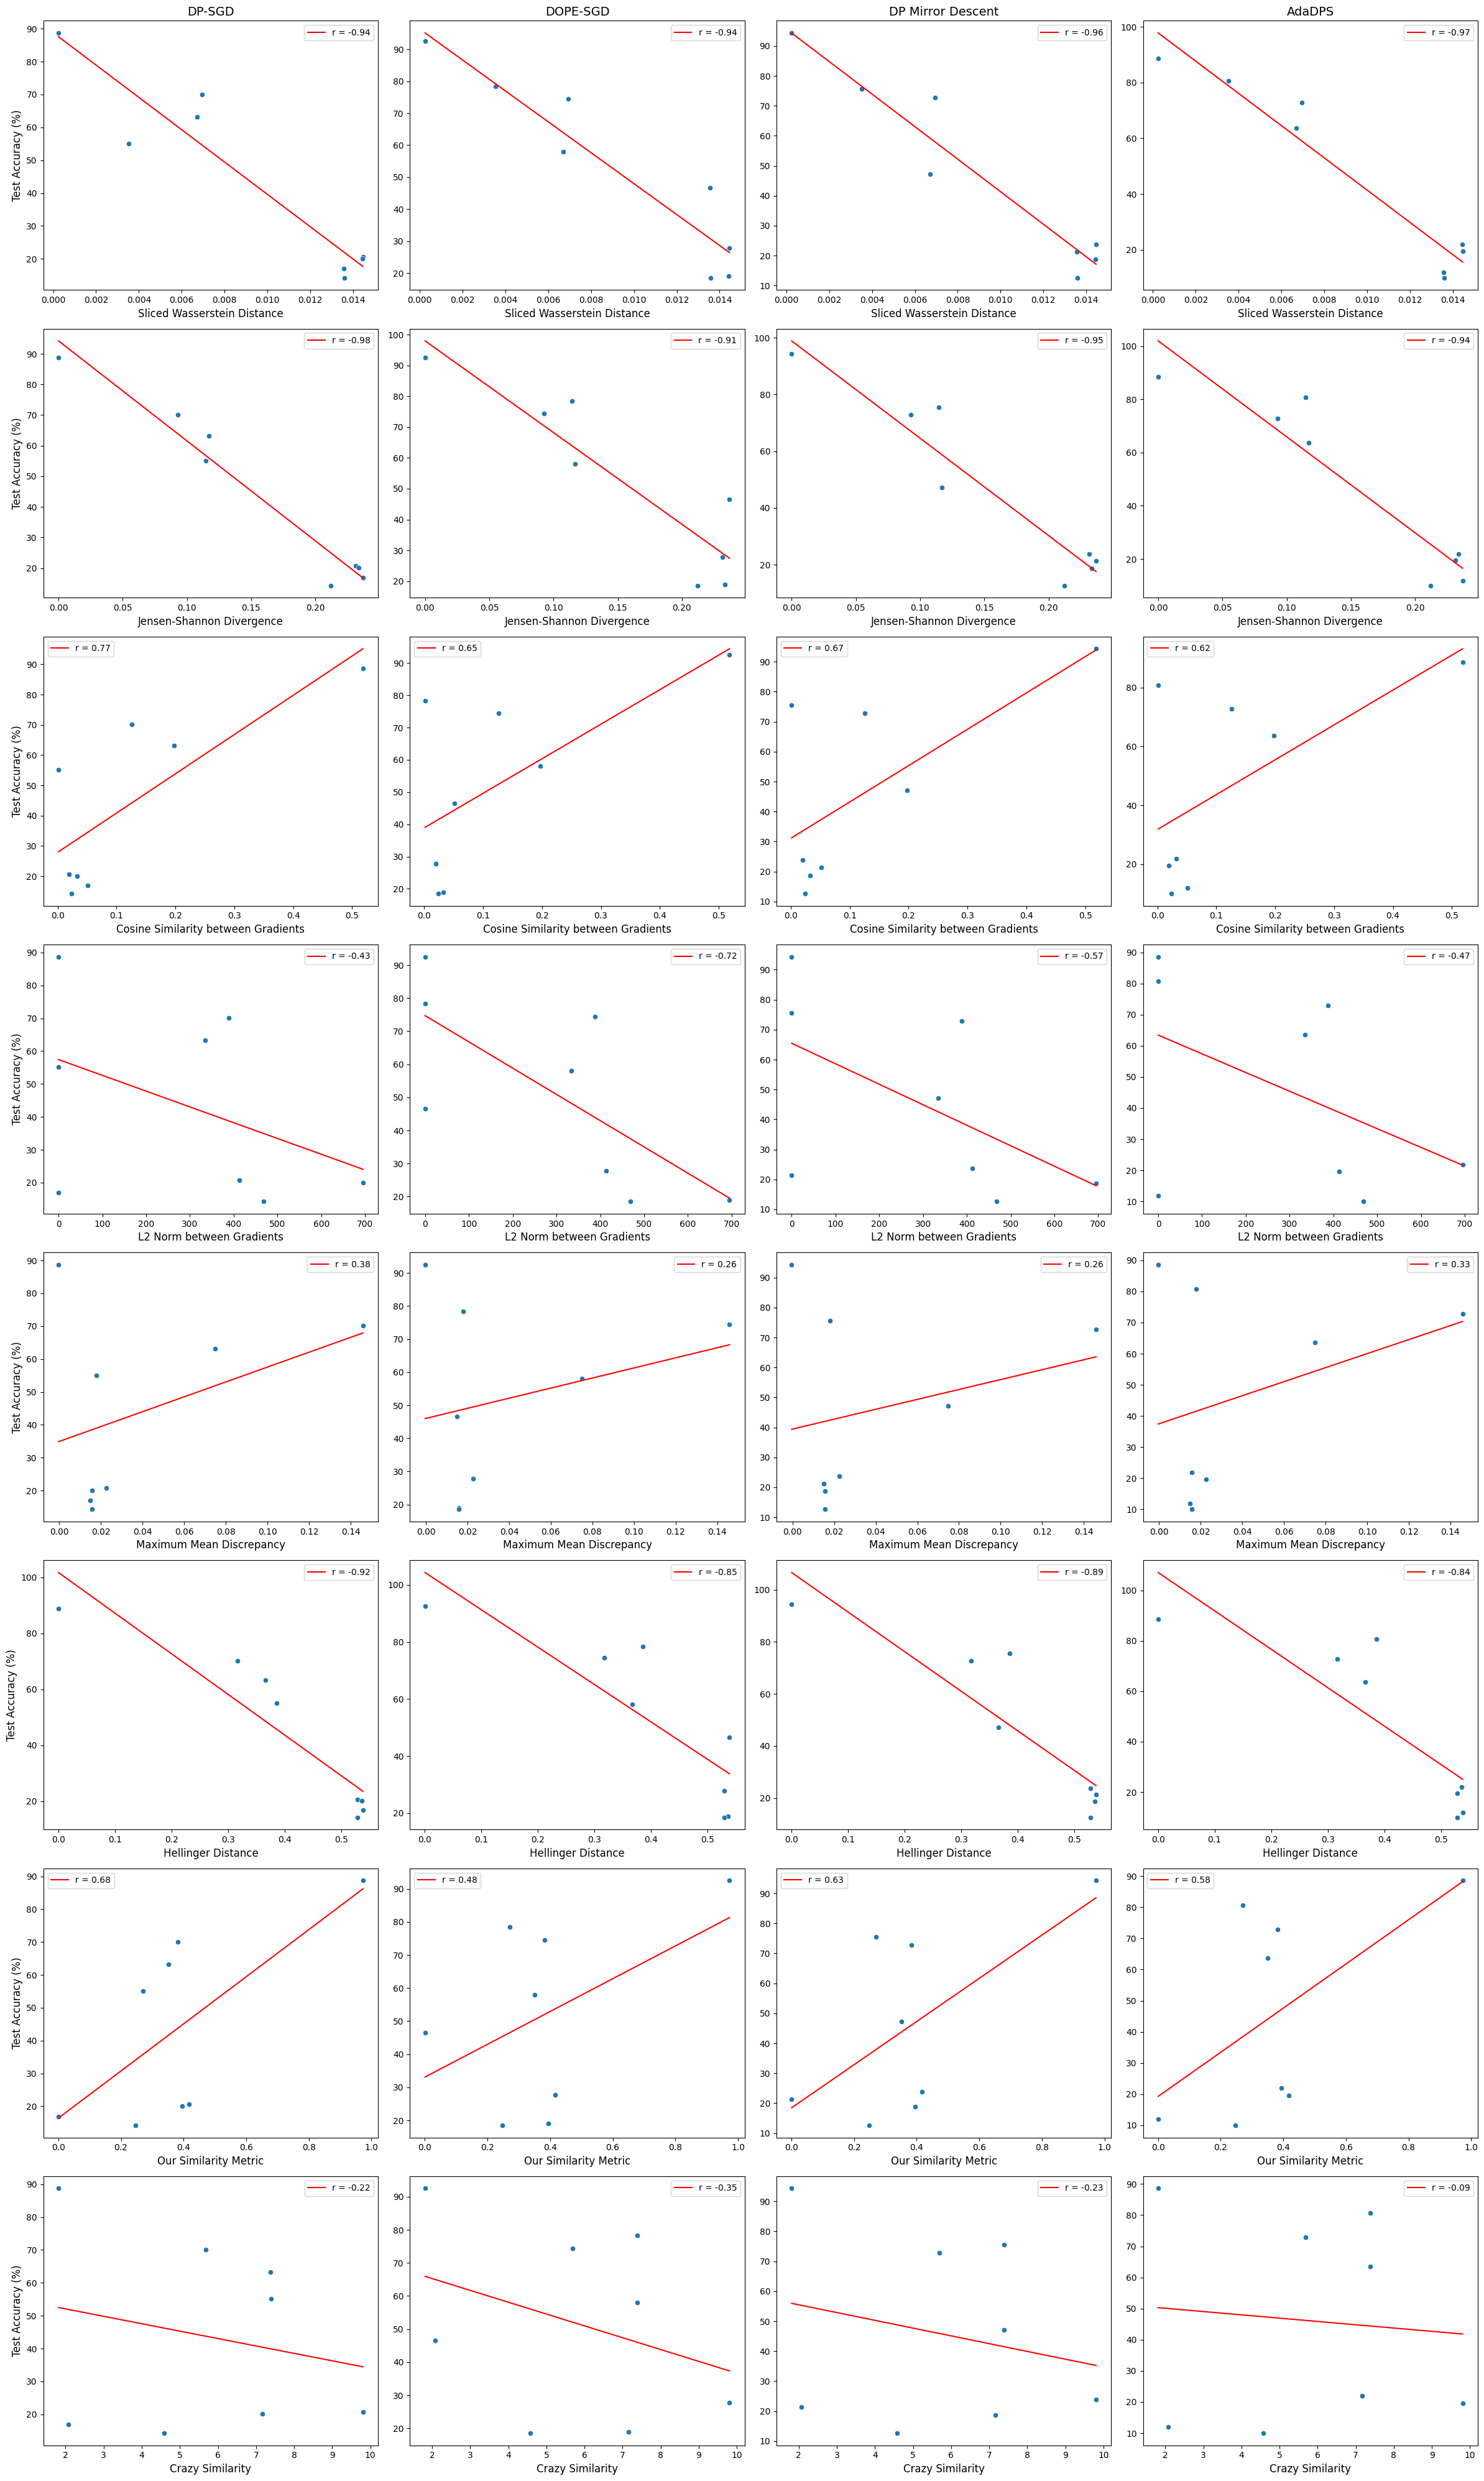

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress


order = ["USPS", "FashionMNIST", "SVHN", "CIFAR-10", "STL-10", "QMNIST", "KMNIST", "SEMEION"]


s_was_sim = [0.003530991563, 0.006940077492, 0.014461491775, 0.014432070567, 0.01358911509, 0.000248053066, 0.006706206547, 0.013562417714]
jsd_sim = [0.114499000000, 0.092713000000, 0.231467000000, 0.233652000000, 0.212181, 0.000000170178, 0.117018167721, 0.236999708724]
cosine_sim = [0.0015, 0.1261, 0.0197, 0.0326, 0.0238, 0.518260598183, 0.197512239218, 0.051266677678]
l2_norm_sim = [0.074, 388.1557, 413.0328, 695.0426, 468.1418, 0.000925271768, 334.347686767578, 0.001943506637]
mmd_sim = [0.017933581, 0.14585292, 0.022628454, 0.015758608, 0.01574812, -0.000386925530, 0.074872170000, 0.014904100000]
hellinger_sim = [0.385654985772, 0.317277278800, 0.528687696487, 0.536272981830, 0.528780144, 0.000443533919, 0.366413510639, 0.538365693953]
#fid_sim = [146.760162353515, 229.598815917968, 190.478591918945, 235.153808593750, 262.777221679687]
our_sim = [0.2707, 0.3825, 0.4167, 0.3947, 0.2475, 0.9727, 0.3510, 0.0007]
crazy_sim = [18.388149975473, 5.688674026957, 9.806939638491, 7.163322011771, 4.580205978194, 1.814514357265, 7.384720720562, 2.075283477288]

basic_dp_sgd = [55.11, 70.08, 20.68, 20.07, 14.26, 88.73, 63.23, 16.93]
basic_dope_sgd = [78.38, 74.46, 27.76, 18.98, 18.54, 92.52, 58.03, 46.58]
basic_mirror_descent = [75.56, 72.80, 23.77, 18.74, 12.65, 94.32, 47.19, 21.32]
basic_ada_dps = [80.72, 72.86, 19.59, 21.91, 10.00, 88.59, 63.62, 11.91]


all_algorithms = {
   "DP-SGD": basic_dp_sgd,
   "DOPE-SGD": basic_dope_sgd,
   "DP Mirror Descent": basic_mirror_descent,
   "AdaDPS": basic_ada_dps,
}


all_similarity_metrics = {
   "Sliced Wasserstein Distance": s_was_sim,
   "Jensen-Shannon Divergence": jsd_sim,
   "Cosine Similarity between Gradients": cosine_sim,
   "L2 Norm between Gradients": l2_norm_sim,
   "Maximum Mean Discrepancy": mmd_sim,
   "Hellinger Distance": hellinger_sim,
   "Our Similarity Metric": our_sim,
   "Crazy Similarity": crazy_sim
   #"Frechet-Inception Distance": fid_sim
}


k = len(all_algorithms)
n = len(all_similarity_metrics)
fig, axes = plt.subplots(nrows=n, ncols=k, figsize=(6 * k, 5 * n), squeeze=False)


for row_idx, (sim_name, sim_values) in enumerate(all_similarity_metrics.items()):
   total_r = 0
   for col_idx, (algo_name, accuracies) in enumerate(all_algorithms.items()):
      
       ax = axes[row_idx][col_idx]


       # Scatter plot
       sns.scatterplot(x=sim_values, y=accuracies, ax=ax)


       # Fit line
       slope, intercept, r_value, _, _ = linregress(sim_values, accuracies)
       total_r += r_value
       x_vals = sorted(sim_values)
       y_vals = [slope * x + intercept for x in x_vals]
       ax.plot(x_vals, y_vals, color='red', label=f'r = {r_value:.2f}')


       # Labeling
       if row_idx == 0:
           ax.set_title(f"{algo_name}", fontsize=14)
       if col_idx == 0:
           ax.set_ylabel("Test Accuracy (%)", fontsize=12)
       else:
           ax.set_ylabel("")
       ax.set_xlabel(f"{sim_name}", fontsize=12)
       ax.legend()
   print(f"{sim_name} - Mean r-value: {total_r/k}")


plt.tight_layout()
plt.show()